In [1]:
import pandas as pd
import numpy as np

from utils.config import load_config
from preprocessing.house_prices_preprocessing import HousePricesPreprocessor
from feature_utils.shap.shap_analysis import (
    fit_best_catboost_for_shap,
    get_shap_importance_df,
    plot_shap_summary,
    plot_shap_bar,
    plot_top_shap_features,
)

In [2]:
config = load_config()

data = pd.read_csv(config["paths"]["train"])

# --- разделяем target ---
target = "SalePrice"

# логарифмируем таргет
y = np.log1p(data[target])

X = data.drop(columns=[target])

# --- preprocessing ---
preprocessor = HousePricesPreprocessor(outlier_quantile=0.95)

X_prepared = preprocessor.fit_transform(X)

X_prepared.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageFinish_Unf,GarageFinish_Fin,GarageFinish_None,BsmtFinType1_GLQ,BsmtFinType1_ALQ,BsmtFinType1_Unf,BsmtFinType1_Rec,BsmtFinType1_BLQ,BsmtFinType1_None,BsmtFinType1_LwQ
0,0.073375,-0.208804,-0.332210,0.651479,-0.517200,1.050994,0.878668,0.739648,0.667140,-0.327561,...,0,0,0,1,0,0,0,0,0,0
1,-0.872563,0.646406,-0.009592,-0.071836,2.179628,0.156734,-0.429577,-0.654947,1.327216,-0.327561,...,0,0,0,0,1,0,0,0,0,0
2,0.073375,-0.037762,0.453294,0.651479,-0.517200,0.984752,0.830215,0.497729,0.133255,-0.327561,...,0,0,0,1,0,0,0,0,0,0
3,0.309859,-0.493874,-0.023619,0.651479,-0.517200,-1.863632,-0.720298,-0.654947,-0.521967,-0.327561,...,1,0,0,0,1,0,0,0,0,0
4,0.073375,0.874462,1.297710,1.374795,-0.517200,0.951632,0.733308,1.835402,0.543376,-0.327561,...,0,0,0,1,0,0,0,0,0,0


In [3]:
model = fit_best_catboost_for_shap(X_prepared, y, random_state=config["seed"])

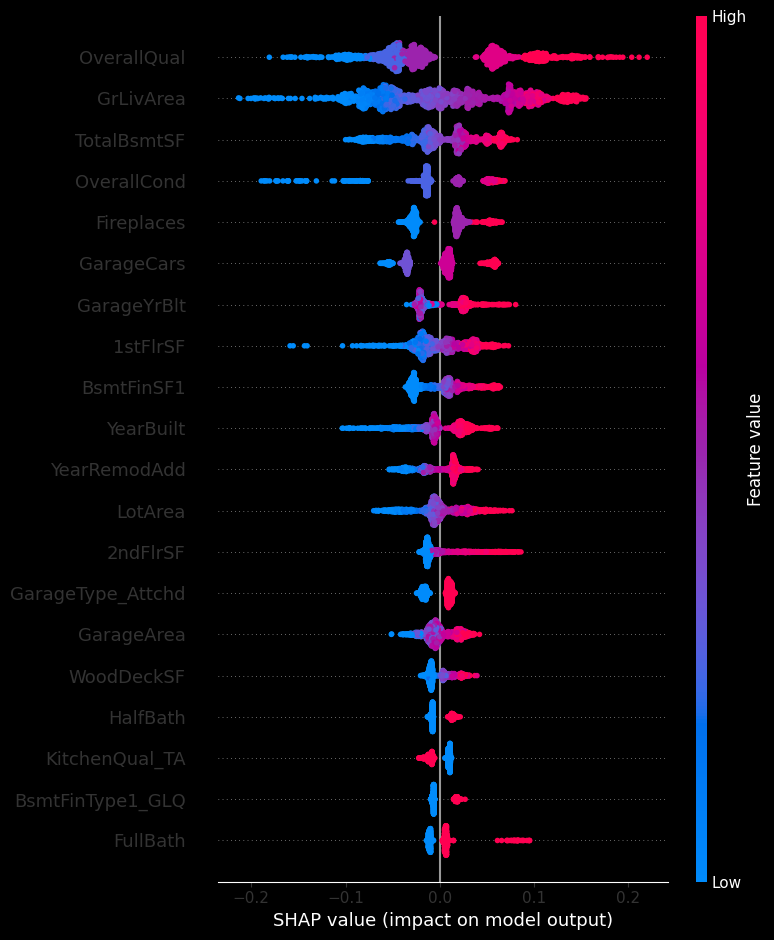

In [4]:
plot_shap_summary(model, X_prepared)

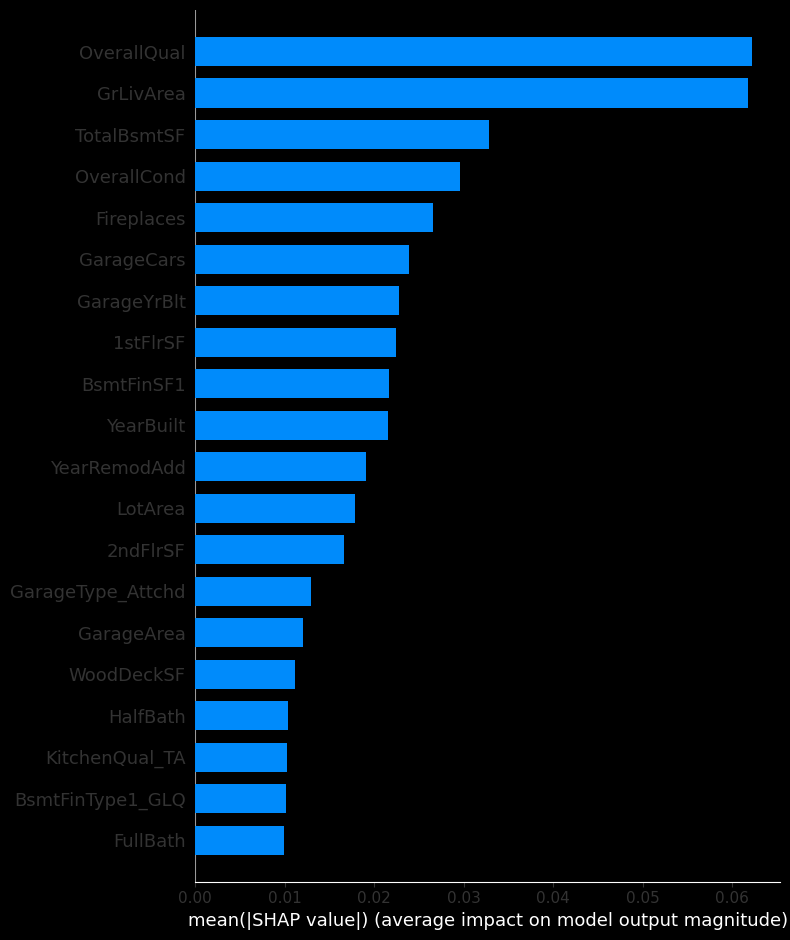

In [5]:
plot_shap_bar(model, X_prepared)

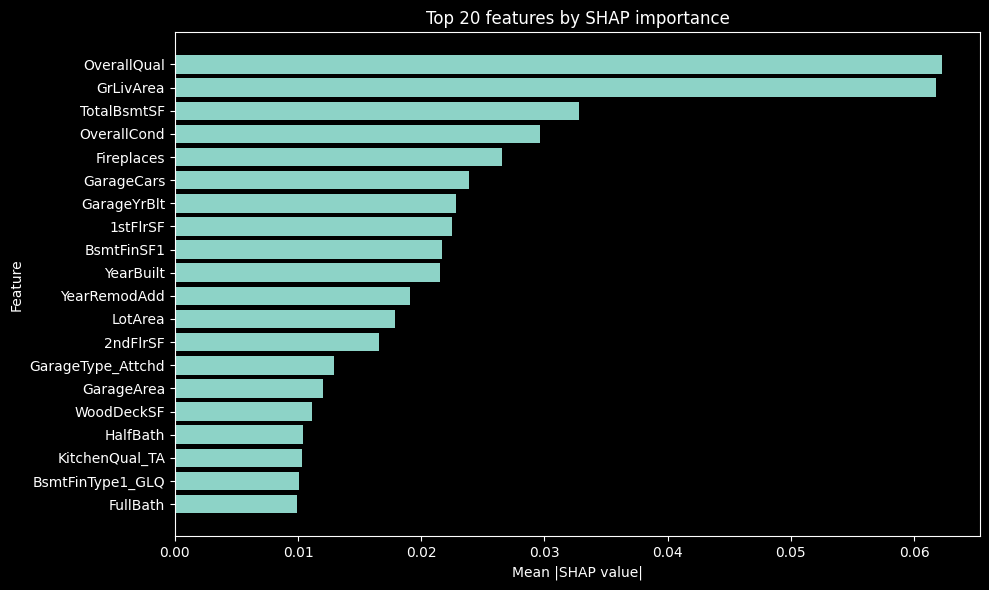

In [6]:
plot_top_shap_features(model, X_prepared, top_n=20)

In [7]:
importance_df = get_shap_importance_df(model, X_prepared)
importance_df.head(30)

,feature,mean_abs_shap
0,OverallQual,0.062243
1,GrLivArea,0.061774
2,TotalBsmtSF,0.032804
3,OverallCond,0.029622
4,Fireplaces,0.026555
5,GarageCars,0.023861
6,GarageYrBlt,0.022814
7,1stFlrSF,0.022471
8,BsmtFinSF1,0.021669
9,YearBuilt,0.021507


# Feature Engineering & SHAP Analysis

## Цель

На этом этапе мы перешли от подбора гиперпараметров к **анализу признаков и их влияния на модель**.

Для этого использовался SHAP (SHapley Additive exPlanations), который позволяет понять:

* какие признаки наиболее важны,
* как именно они влияют на предсказание модели,
* какие взаимодействия между признаками стоит добавить.

---

## Основные выводы из SHAP

### Самые важные признаки

По SHAP-анализу топ признаков:

* `OverallQual` — качество дома (самый важный фактор)
* `GrLivArea` — жилая площадь
* `TotalBsmtSF` — площадь подвала
* `OverallCond` — общее состояние
* `Fireplaces` — количество каминов
* `GarageCars`, `GarageArea` — характеристики гаража
* `YearBuilt`, `YearRemodAdd` — возраст дома и ремонта

---

## Интерпретация модели

### 1. Качество дома (`OverallQual`)

* Чем выше качество → тем выше цена
* Самый сильный линейный фактор

### 2. Площадь (`GrLivArea`, `TotalBsmtSF`)

* Больше площадь → выше цена
* Эффект почти линейный

### 3. Возраст (`YearBuilt`, `YearRemodAdd`)

* Новые дома дороже
* Недавний ремонт также увеличивает стоимость

### 4. Гараж (`GarageCars`, `GarageArea`)

* Размер и вместимость гаража существенно влияют на цену

---

## Новые признаки (Feature Engineering)

На основе SHAP были добавлены следующие признаки:

---

### 1. Общая площадь дома

```python
TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF
```

Объединяет все этажи → сильный агрегированный признак

---

### 2. Возраст дома

```python
HouseAge = YrSold - YearBuilt
```

Старые дома дешевле

---

### 🔧 3. Возраст ремонта

```python
RemodAge = YrSold - YearRemodAdd
```

📌 Чем новее ремонт → тем выше цена

---

### 4. Качество × площадь

```python
Qual_x_LivArea = OverallQual * GrLivArea
Qual_x_TotalSF = OverallQual * TotalSF
```

Очень сильные interaction-признаки
Позволяют модели учитывать “дорогие большие дома”

---

### 5. Гаражный скор

```python
GarageScore = GarageCars * GarageArea
```

Комбинация вместимости и размера гаража

---

### 6. Суммарные ванные

```python
TotalBathrooms = (
    FullBath +
    0.5 * HalfBath +
    BsmtFullBath +
    0.5 * BsmtHalfBath
)
```

Более точная оценка удобства дома

---

### 7. Бинарные признаки

```python
HasFireplace = Fireplaces > 0
HasGarage = GarageArea > 0
HasBsmt = TotalBsmtSF > 0
Has2ndFloor = 2ndFlrSF > 0
```

Простые, но полезные признаки наличия

---

## Важное замечание

* Не все слабые признаки были удалены
* SHAP показывает важность, но:

  * слабые признаки могут участвовать во взаимодействиях
  * удаление может ухудшить качество

Поэтому удаление признаков требует отдельной проверки через CV

---

## Дальнейшие шаги

1. Прогнать модель с новым препроцессором
2. Сравнить RMSE с предыдущими результатами
3. Добавить новые interaction-признаки при необходимости

---

Feature engineering — основной источник улучшения модели на этом этапе
